In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("riffatsiddiqui/ceramic-tiles-defects-crackspotspinhole")

print("Path to dataset files:", path)

: 

In [1]:
print("hello world")

hello world


In [ ]:
# Standard Library Imports
from collections import defaultdict
import os
import re
from pathlib import Path

# Third-Party Libraries (Data & Image Processing)
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# Optional / Commented out in original script
# import albumentations as A
# from sklearn.model_selection import train_test_split

# Deep Learning Framework (PyTorch & Timm)
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

In [9]:
dataset_path = Path("dataset")
total_images = len(list(dataset_path.glob("*.jpg")))

print(f"Total gambar: {total_images}")

Total gambar: 12483


Total gambar ditemukan: 12483

[PASS-1] Mendeteksi gambar blank...
Gambar blank ditemukan  : 12
Total gambar valid      : 12471

[PASS-2] Menganalisis gambar valid...

            HASIL ANALISIS DATASET DEFEK

[1] KETEBALAN RATA-RATA GARIS RETAK
    → 74.81 pixel  (dari 12471 gambar berisi retak)

[2] GAMBAR BLANK (dikeluarkan dari analisis)
    → 12 gambar ditemukan:
       • crack.112.jpg  [HITAM]
       • crack.1724.jpg  [HITAM]
       • crack.2088.jpg  [HITAM]
       • crack.2264.jpg  [HITAM]
       • crack.2321.jpg  [HITAM]
       • crack.2392.jpg  [HITAM]
       • crack.3313.jpg  [HITAM]
       • crack.3634.jpg  [HITAM]
       • crack.4255.jpg  [HITAM]
       • crack.4515.jpg  [HITAM]
       • crack.5273.jpg  [HITAM]
       • crack.5444.jpg  [HITAM]

[3] JUMLAH DEFEK BERDASARKAN NAMA FILE
    Pola: crack.*.jpg | spot.*.jpg | pinhole.*.jpg
    Jenis        Jumlah
    --------------------
    crack          5903
    spot           6568
    --------------------
    TOTAL         124

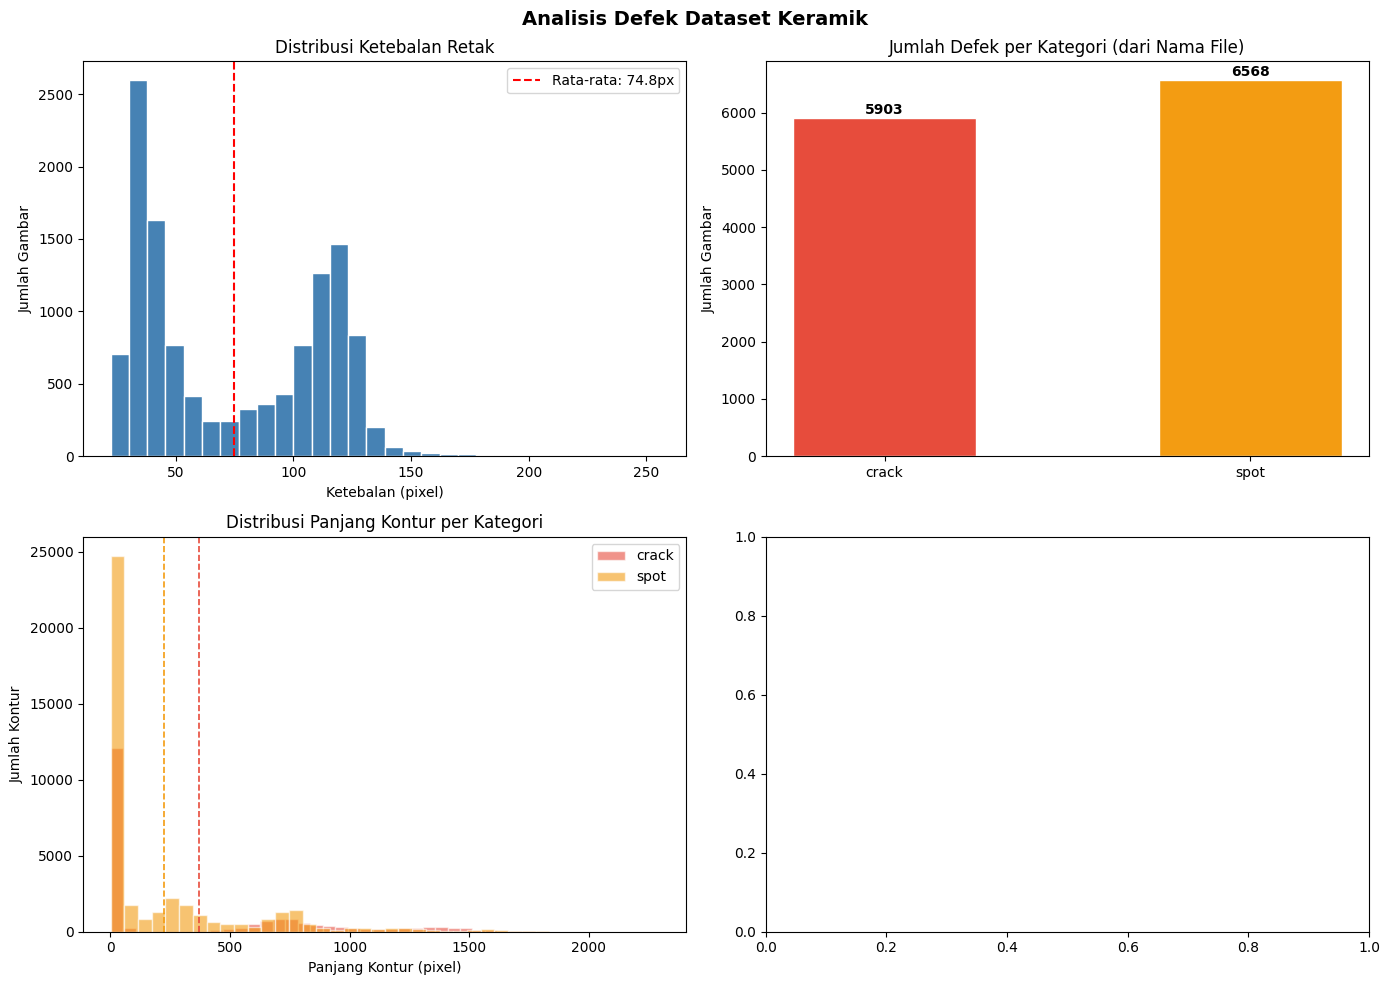

In [ ]:
#(DAFFA S)
# ── KONFIGURASI ──────────────────────────────────────────────────────────────
#dataset_path = 'ceramic_tiles_defects/dataset/'

# ── HELPER: kumpulkan semua path gambar ──────────────────────────────────────
def collect_image_paths(root):
    exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif')
    paths = []
    for dirpath, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(exts):
                paths.append(os.path.join(dirpath, f))
    return paths

image_paths = collect_image_paths(dataset_path)
print(f"Total gambar ditemukan: {len(image_paths)}")

# ── 1. HITUNG KETEBALAN RATA-RATA GARIS RETAK ────────────────────────────────
def measure_crack_thickness(gray):
    _, binary = cv2.threshold(gray, 0, 255,
                               cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    if binary.sum() == 0:
        return 0.0
    if np.all(binary == 255):
        return 0.0
    dist = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
    nonzero = dist[dist > 0]
    if len(nonzero) == 0:
        return 0.0
    return float(np.mean(nonzero) * 2)

# ── 2. DETEKSI GAMBAR HITAM / PUTIH TOTAL ────────────────────────────────────
def is_blank(gray, threshold=10):
    mean_val = np.mean(gray)
    std_val  = np.std(gray)
    if std_val < threshold:
        if mean_val < 30:
            return 'HITAM'
        elif mean_val > 225:
            return 'PUTIH'
        else:
            return 'SOLID (abu-abu)'
    return None

# ── 3. KLASIFIKASI DEFEK BERDASARKAN NAMA FILE ───────────────────────────────
DEFECT_PATTERNS = {
    'crack'  : re.compile(r'^crack\..+',   re.IGNORECASE),
    'spot'   : re.compile(r'^spot\..+',    re.IGNORECASE),
    'pinhole': re.compile(r'^pinhole\..+', re.IGNORECASE),
}

def classify_by_filename(filename):
    for defect_type, pattern in DEFECT_PATTERNS.items():
        if pattern.match(filename):
            return defect_type
    return None

# ── 4. UKUR PANJANG KONTUR DARI GAMBAR ───────────────────────────────────────
def get_contour_lengths(gray):
    _, binary = cv2.threshold(gray, 0, 255,
                               cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    return [cv2.arcLength(cnt, closed=False) for cnt in contours if cv2.arcLength(cnt, closed=False) > 0]

# ── LOOP PASS-1: DETEKSI BLANK ────────────────────────────────────────────────
# Dilakukan terlebih dahulu agar gambar blank tidak ikut dihitung di analisis
print("\n[PASS-1] Mendeteksi gambar blank...")
blank_images = []

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        continue
    gray       = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blank_type = is_blank(gray)
    if blank_type:
        blank_images.append((os.path.basename(path), blank_type))

# ── FILTER BLANK ──────────────────────────────────────────────────────────────
blank_image_filenames = [fname for fname, _ in blank_images]

image_paths = [
    path for path in image_paths
    if os.path.basename(path) not in blank_image_filenames
]
print(f"Gambar blank ditemukan  : {len(blank_image_filenames)}")
print(f"Total gambar valid      : {len(image_paths)}")

# ── LOOP PASS-2: ANALISIS UTAMA (hanya gambar valid) ─────────────────────────
print("\n[PASS-2] Menganalisis gambar valid...")
all_thicknesses       = []
total_defects         = defaultdict(int)
per_image_results     = []
lengths_per_category  = {'crack': [], 'spot': [], 'pinhole': [], 'unknown': []}

for path in image_paths:
    img = cv2.imread(path)
    if img is None:
        print(f"[SKIP] Tidak bisa dibaca: {path}")
        continue
    gray     = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    filename = os.path.basename(path)

    # 1 – ketebalan
    thickness = measure_crack_thickness(gray)
    all_thicknesses.append(thickness)

    # 2 – klasifikasi berdasarkan nama file
    defect_type = classify_by_filename(filename) or 'unknown'
    total_defects[defect_type] += 1

    # 3 – ukur panjang kontur, masukkan ke kategori yang sesuai
    lengths = get_contour_lengths(gray)
    lengths_per_category[defect_type].extend(lengths)

    per_image_results.append({
        'file'     : filename,
        'thickness': round(thickness, 2),
        'defect'   : defect_type,
    })

# ── LAPORAN ───────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("            HASIL ANALISIS DATASET DEFEK")
print("="*60)

# 1
valid_thick = [t for t in all_thicknesses if t > 0]
avg_thick   = np.mean(valid_thick) if valid_thick else 0
print(f"\n[1] KETEBALAN RATA-RATA GARIS RETAK")
print(f"    → {avg_thick:.2f} pixel  (dari {len(valid_thick)} gambar berisi retak)")

# 2
print(f"\n[2] GAMBAR BLANK (dikeluarkan dari analisis)")
if blank_images:
    print(f"    → {len(blank_images)} gambar ditemukan:")
    for fname, btype in blank_images:
        print(f"       • {fname}  [{btype}]")
else:
    print("    → Tidak ada gambar blank.")

# 3
print(f"\n[3] JUMLAH DEFEK BERDASARKAN NAMA FILE")
print(f"    Pola: crack.*.jpg | spot.*.jpg | pinhole.*.jpg")
print(f"    {'Jenis':<10} {'Jumlah':>8}")
print(f"    {'-'*20}")
for dtype in ['crack', 'spot', 'pinhole', 'unknown']:
    if total_defects[dtype] > 0:
        print(f"    {dtype:<10} {total_defects[dtype]:>8}")
print(f"    {'-'*20}")
print(f"    {'TOTAL':<10} {sum(total_defects.values()):>8}")

# 4
print(f"\n[4] DISTRIBUSI PANJANG KONTUR PER KATEGORI (pixel)")
print(f"    {'Kategori':<10} {'Jml Kontur':>12} {'Min':>8} {'Max':>8} {'Rata-rata':>10} {'Median':>8}")
print(f"    {'-'*60}")
for dtype in ['crack', 'spot', 'pinhole', 'unknown']:
    lens = lengths_per_category[dtype]
    if lens:
        print(f"    {dtype:<10} {len(lens):>12} {min(lens):>8.1f} {max(lens):>8.1f} "
              f"{np.mean(lens):>10.1f} {np.median(lens):>8.1f}")
    else:
        print(f"    {dtype:<10} {'0':>12} {'-':>8} {'-':>8} {'-':>10} {'-':>8}")

# ── VISUALISASI ───────────────────────────────────────────────────────────────
CATEGORY_COLORS = {
    'crack'  : '#e74c3c',
    'spot'   : '#f39c12',
    'pinhole': '#3498db',
    'unknown': '#95a5a6',
}
main_types = ['crack', 'spot', 'pinhole']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Analisis Defek Dataset Keramik', fontsize=14, fontweight='bold')

# ── Plot 1: Distribusi Ketebalan ──────────────────────────────────────────────
axes[0, 0].hist(valid_thick, bins=30, color='steelblue', edgecolor='white')
axes[0, 0].axvline(avg_thick, color='red', linestyle='--',
                   label=f'Rata-rata: {avg_thick:.1f}px')
axes[0, 0].set_title('Distribusi Ketebalan Retak')
axes[0, 0].set_xlabel('Ketebalan (pixel)')
axes[0, 0].set_ylabel('Jumlah Gambar')
axes[0, 0].legend()

# ── Plot 2: Jumlah Defek per Kategori ────────────────────────────────────────
labels = [t for t in main_types if total_defects[t] > 0]
values = [total_defects[t] for t in labels]
colors = [CATEGORY_COLORS[t] for t in labels]
bars   = axes[0, 1].bar(labels, values, color=colors, edgecolor='white', width=0.5)
axes[0, 1].set_title('Jumlah Defek per Kategori (dari Nama File)')
axes[0, 1].set_ylabel('Jumlah Gambar')
for bar, val in zip(bars, values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(values) * 0.01,
                    str(val), ha='center', fontweight='bold')

# ── Plot 3: Histogram Panjang Kontur per Kategori ────────────────────────────
for dtype in main_types:
    lens = lengths_per_category[dtype]
    if lens:
        axes[1, 0].hist(lens, bins=40, alpha=0.6,
                        color=CATEGORY_COLORS[dtype],
                        edgecolor='white', label=dtype)
        axes[1, 0].axvline(np.mean(lens), color=CATEGORY_COLORS[dtype],
                           linestyle='--', linewidth=1.2)
axes[1, 0].set_title('Distribusi Panjang Kontur per Kategori')
axes[1, 0].set_xlabel('Panjang Kontur (pixel)')
axes[1, 0].set_ylabel('Jumlah Kontur')
axes[1, 0].legend()

# ── Plot 4: Boxplot Panjang Kontur per Kategori ───────────────────────────────


plt.tight_layout()
plt.show()

In [ ]:


# ── Asumsi: Variabel `image_paths` di bawah ini adalah hasil filter dari kode EDA Anda ──
# image_paths = [path for path in image_paths if os.path.basename(path) not in blank_image_filenames]

# ── 1. FUNGSI KLASIFIKASI (Sama seperti di EDA) ───────────────────────────────
DEFECT_PATTERNS = {
    'crack'  : re.compile(r'crack',   re.IGNORECASE),
    'spot'   : re.compile(r'spot',    re.IGNORECASE),
    'pinhole': re.compile(r'pinhole', re.IGNORECASE),
}

def classify_by_path(filepath):
    parent_folder = os.path.basename(os.path.dirname(filepath)).lower()
    for defect_type, pattern in DEFECT_PATTERNS.items():
        if pattern.search(parent_folder):
            return defect_type
    filename = os.path.basename(filepath).lower()
    for defect_type, pattern in DEFECT_PATTERNS.items():
        if pattern.search(filename):
            return defect_type
    return 'unknown'

# ── 2. PERSIAPAN PATH & LABEL (Menggunakan data yang sudah difilter) ─────────
# Memisahkan path dan label, membuang 'unknown' jika ada
valid_paths = []
valid_labels_str = []

for path in image_paths: # <--- INI VARIABEL HASIL FILTER EDA ANDA
    label = classify_by_path(path)
    if label != 'unknown': # Abaikan jika tidak ada polanya
        valid_paths.append(path)
        valid_labels_str.append(label)

# Mapping Label String ke Integer (wajib untuk PyTorch)
unique_classes = sorted(list(set(valid_labels_str)))
class_to_idx = {cls_name: i for i, cls_name in enumerate(unique_classes)}
valid_labels_int = [class_to_idx[lbl] for lbl in valid_labels_str]

NUM_CLASSES = len(unique_classes)
print(f"Kelas terdeteksi: {unique_classes}")
print(f"Jumlah data valid (tanpa blank): {len(valid_paths)}")

# ── 3. CUSTOM DATASET ────────────────────────────────────────────────────────
class CeramicDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Baca gambar, konversi ke RGB (DINOv2 butuh 3 channel)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# ── 4. PREPROCESSING & AUGMENTASI ────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # Pastikan biner jadi 3 channel identik
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# ── 5. MEMUAT DATASET & SPLIT 80:20 ──────────────────────────────────────────
full_dataset = CeramicDataset(valid_paths, valid_labels_int, transform=transform)

total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ── 6. MODEL DINOv2 dari timm ────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('vit_small_patch14_dinov2.lvd142m', pretrained=True)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# ── 7. TRAINING LOOP ─────────────────────────────────────────────────────────
STEPS_PER_EPOCH = 150
best_val_acc = 0.0
epoch_count = 0

print("\nMemulai Training...")
print("="*50)

while True:
    epoch_count += 1
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    # Training dengan batas 150 step
    train_pbar = tqdm(enumerate(train_loader), total=STEPS_PER_EPOCH, desc=f"Epoch {epoch_count} [Train]")
    for step, (images, labels) in train_pbar:
        if step >= STEPS_PER_EPOCH:
            break
            
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
        train_pbar.set_postfix(loss=running_loss/(step+1), acc=100.*correct_train/total_train)

    train_acc = 100. * correct_train / total_train

    # ── VALIDATION ────────────────────────────────────────────────────────────
    model.eval()
    correct_val = 0
    total_val = 0
    val_loss = 0.0
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch_count} [Val]")
        for images, labels in val_pbar:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
            val_pbar.set_postfix(acc=100.*correct_val/total_val)

    current_val_acc = 100. * correct_val / total_val
    
    print(f"\nRingkasan Epoch {epoch_count}:")
    print(f"Train Acc: {train_acc:.2f}% | Val Acc: {current_val_acc:.2f}% | Best Val Acc: {best_val_acc:.2f}%")
    print("-"*50)

    # ── EARLY STOPPING: Jika akurasi menurun ─────────────────────────────────
    if current_val_acc < best_val_acc:
        print(f"\n[EARLY STOP] Akurasi validasi menurun dari {best_val_acc:.2f}% menjadi {current_val_acc:.2f}%.")
        print("Training dihentikan.")
        break
    else:
        best_val_acc = current_val_acc
        torch.save(model.state_dict(), 'best_model_dinov2.pth')
        print(f"Model disimpan (Akurasi meningkat/menjadi {best_val_acc:.2f}%)")

print("Training selesai.")